<a href="https://colab.research.google.com/github/Viv-Dave/deep-learning/blob/main/localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms

import os
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class PetDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')
        self.xml_dir = os.path.join(root_dir, 'annotations', 'xmls')

        image_basenames = {os.path.splitext(f)[0] for f in os.listdir(self.image_dir) if f.endswith('.jpg')}
        xml_basenames = {os.path.splitext(f)[0] for f in os.listdir(self.xml_dir) if f.endswith('.xml')}
        self.valid_basenames = sorted(list(image_basenames.intersection(xml_basenames)))
        self.image_files = [f + '.jpg' for f in self.valid_basenames]

        print(f"Found {len(self.image_files)} valid image-annotation pairs.")

        self.class_to_idx, self.idx_to_class = self._create_class_mapping()

    def _create_class_mapping(self):
        class_names = sorted(list(set([f.rsplit('_', 1)[0] for f in self.image_files])))
        class_to_idx = {name: i for i, name in enumerate(class_names)}
        idx_to_class = {i: name for name, i in class_to_idx.items()}
        return class_to_idx, idx_to_class

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        xml_name = img_name.replace('.jpg', '.xml')
        xml_path = os.path.join(self.xml_dir, xml_name)

        image = Image.open(img_path).convert("RGB")
        original_width, original_height = image.size

        tree = ET.parse(xml_path)
        root = tree.getroot()

        class_name_from_filename = img_name.rsplit('_', 1)[0]
        class_idx = self.class_to_idx[class_name_from_filename]

        obj = root.find('object')
        bndbox = obj.find('bndbox')
        xmin = float(bndbox.find('xmin').text)
        ymin = float(bndbox.find('ymin').text)
        xmax = float(bndbox.find('xmax').text)
        ymax = float(bndbox.find('ymax').text)

        bbox_normalized = [
            xmin / original_width,
            ymin / original_height,
            xmax / original_width,
            ymax / original_height
        ]

        if self.transform:
            image = self.transform(image)

        class_label = torch.tensor(class_idx, dtype=torch.long)
        bbox_label = torch.tensor(bbox_normalized, dtype=torch.float32)

        return image, (class_label, bbox_label)

In [ ]:
print("Downloading images...")
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
print("Downloading annotations...")
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!mkdir -p ./data/oxford-iiit-pet

print("Extracting images and annotations...")
!tar -xzf images.tar.gz -C ./data/oxford-iiit-pet/
!tar -xzf annotations.tar.gz -C ./data/oxford-iiit-pet/

print("Data setup complete! The folder structure is now correct.")


--2025-06-29 11:17:33--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2025-06-29 11:17:35--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  22.1MB/s    in 37s     

2025-06-29 11:18:13 (20.1 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2025-06-29 11:18:13--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [ ]:
class ObjectLocalizationModel(nn.Module):
    def __init__(self, backbone, bbox_head, classification_head):
        super().__init__()
        self.backbone = backbone
        self.bbox_head = bbox_head
        self.classification_head = classification_head
        self.flatten = nn.Flatten()

    def forward(self, x):
        features = self.backbone(x)
        flattened_features = self.flatten(features)
        bbox_predictions = self.bbox_head(flattened_features)
        class_predictions = self.classification_head(flattened_features)
        return class_predictions, bbox_predictions

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
pet_dataset = PetDataset(root_dir='/content/data/oxford-iiit-pet', transform=image_transforms)
train_loader = DataLoader(pet_dataset, batch_size=32, shuffle=True, num_workers=2)

num_classes = len(pet_dataset.class_to_idx)
box_coordinates = 4
in_features = 512 * 7 * 7

print(f"Building model with {num_classes} classes and {box_coordinates} box coordinates.")

vgg_backbone = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
for param in vgg_backbone.parameters():
    param.requires_grad = False

DENSE_LAYER_SIZE = 512

print(f"Using dense layer size of {DENSE_LAYER_SIZE} to conserve memory.")

bbox_head = nn.Sequential(
    nn.Linear(in_features=in_features, out_features=DENSE_LAYER_SIZE), # Smaller
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=DENSE_LAYER_SIZE, out_features=box_coordinates)
)
classification_head = nn.Sequential(
    nn.Linear(in_features=in_features, out_features=DENSE_LAYER_SIZE), # Smaller
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=DENSE_LAYER_SIZE, out_features=num_classes)
)

print("Creating the full model...")
model = ObjectLocalizationModel(vgg_backbone, bbox_head, classification_head).to(device)
print("Model created and moved to device successfully.")

class_criterion = nn.CrossEntropyLoss()
bbox_criterion = nn.MSELoss()
BBOX_LOSS_WEIGHT = 10.0

Found 3686 valid image-annotation pairs.
Building model with 37 classes and 4 box coordinates.


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 142MB/s]


Using dense layer size of 512 to conserve memory.
Creating the full model...
Model created and moved to device successfully.


In [ ]:
print("\n--- Starting Training Phase 1 (Heads Only) ---")
params_to_update = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(params_to_update, lr=0.001)

epochs_heads_only = 5
model.train()
for epoch in range(epochs_heads_only):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        images, (true_classes, true_bboxes) = data
        images, true_classes, true_bboxes = images.to(device), true_classes.to(device), true_bboxes.to(device)
        optimizer.zero_grad()
        pred_classes, pred_bboxes = model(images)
        class_loss = class_criterion(pred_classes, true_classes)
        bbox_loss = bbox_criterion(pred_bboxes, true_bboxes)
        total_loss = class_loss + (bbox_loss * BBOX_LOSS_WEIGHT)
        total_loss.backward()
        optimizer.step()
        running_loss += total_loss.item()
        if (i + 1) % 50 == 0:
            print(f'[Head Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 50:.4f}')
            running_loss = 0.0

print('Finished Training (Heads Only)')


--- Starting Training Phase 1 (Heads Only) ---
[Head Epoch 1, Batch 50] loss: 9.9835
[Head Epoch 1, Batch 100] loss: 3.9642
[Head Epoch 2, Batch 50] loss: 3.8520
[Head Epoch 2, Batch 100] loss: 3.8312
[Head Epoch 3, Batch 50] loss: 3.8416
[Head Epoch 3, Batch 100] loss: 3.7992
[Head Epoch 4, Batch 50] loss: 3.7442
[Head Epoch 4, Batch 100] loss: 3.7106
[Head Epoch 5, Batch 50] loss: 3.7213
[Head Epoch 5, Batch 100] loss: 3.6427
Finished Training (Heads Only)


In [ ]:
print("\n--- Starting Training Phase 2 (Fine-Tuning) ---")
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.00001)
epochs_fine_tune = 10

model.train()
for epoch in range(epochs_fine_tune):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        images, (true_classes, true_bboxes) = data
        images, true_classes, true_bboxes = images.to(device), true_classes.to(device), true_bboxes.to(device)
        optimizer.zero_grad()
        pred_classes, pred_bboxes = model(images)
        class_loss = class_criterion(pred_classes, true_classes)
        bbox_loss = bbox_criterion(pred_bboxes, true_bboxes)
        total_loss = class_loss + (bbox_loss * BBOX_LOSS_WEIGHT)
        total_loss.backward()
        optimizer.step()
        running_loss += total_loss.item()
        if (i + 1) % 50 == 0:
            print(f'[Fine-Tune Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 50:.4f}')
            running_loss = 0.0

print('Finished Fine-Tuning')

torch.save(model.state_dict(), 'pet_localizer_model.pth')
print("Model saved to pet_localizer_model.pth")



--- Starting Training Phase 2 (Fine-Tuning) ---
[Fine-Tune Epoch 1, Batch 50] loss: 3.6082
[Fine-Tune Epoch 1, Batch 100] loss: 3.5678
[Fine-Tune Epoch 2, Batch 50] loss: 3.5738
[Fine-Tune Epoch 2, Batch 100] loss: 3.5721
[Fine-Tune Epoch 3, Batch 50] loss: 3.5461
[Fine-Tune Epoch 3, Batch 100] loss: 3.5526
[Fine-Tune Epoch 4, Batch 50] loss: 3.5485
[Fine-Tune Epoch 4, Batch 100] loss: 3.5382
[Fine-Tune Epoch 5, Batch 50] loss: 3.5210
[Fine-Tune Epoch 5, Batch 100] loss: 3.5669
[Fine-Tune Epoch 6, Batch 50] loss: 3.5359
[Fine-Tune Epoch 6, Batch 100] loss: 3.5374
[Fine-Tune Epoch 7, Batch 50] loss: 3.5279
[Fine-Tune Epoch 7, Batch 100] loss: 3.5112
[Fine-Tune Epoch 8, Batch 50] loss: 3.5270
[Fine-Tune Epoch 8, Batch 100] loss: 3.4756
[Fine-Tune Epoch 9, Batch 50] loss: 3.4986
[Fine-Tune Epoch 9, Batch 100] loss: 3.5108
[Fine-Tune Epoch 10, Batch 50] loss: 3.5023
[Fine-Tune Epoch 10, Batch 100] loss: 3.4912
Finished Fine-Tuning
Model saved to pet_localizer_model.pth



--- Making a sample prediction ---


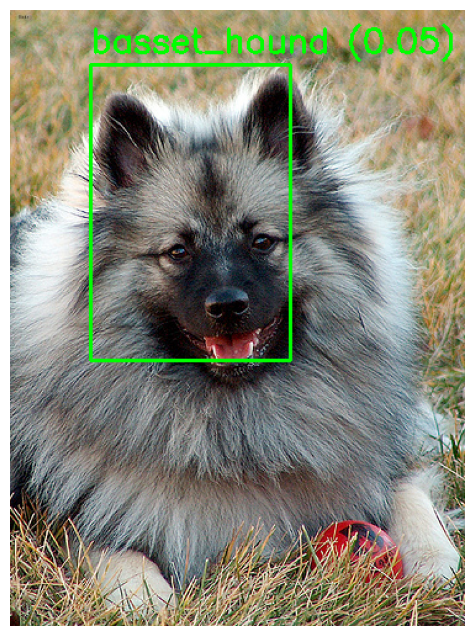

In [ ]:
import cv2 as cv2
def predict_and_visualize(model, image_path, transform, idx_to_class, device):
    model.eval()
    image_pil = Image.open(image_path).convert("RGB")
    original_width, original_height = image_pil.size
    image_tensor = transform(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_class_logits, pred_bbox = model(image_tensor)
        pred_probs = torch.softmax(pred_class_logits, dim=1)
        pred_class_prob, pred_class_idx = torch.max(pred_probs, 1)
        predicted_class_name = idx_to_class[pred_class_idx.item()]

        bbox = pred_bbox[0].cpu().numpy()
        xmin = int(bbox[0] * original_width)
        ymin = int(bbox[1] * original_height)
        xmax = int(bbox[2] * original_width)
        ymax = int(bbox[3] * original_height)

    image_cv = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
    cv2.rectangle(image_cv, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    label_text = f"{predicted_class_name} ({pred_class_prob.item():.2f})"
    cv2.putText(image_cv, label_text, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

print("\n--- Making a sample prediction ---")
test_image_path = os.path.join('/content/data/oxford-iiit-pet', 'images/keeshond_100.jpg')
predict_and_visualize(model, test_image_path, image_transforms, pet_dataset.idx_to_class, device)